# 1. Preprocessing

## a. Data load and check
Memeriksa informasi-informasi awal dari data

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [72]:
df = pd.DataFrame(pd.read_csv("Student_Mental_health.csv"))
df

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...
96,13/07/2020 19:56:49,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
97,13/07/2020 21:21:42,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No
98,13/07/2020 21:22:56,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No
99,13/07/2020 21:23:57,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No


In [73]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    str    
 1   Choose your gender                            101 non-null    str    
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    str    
 4   Your current year of Study                    101 non-null    str    
 5   What is your CGPA?                            101 non-null    str    
 6   Marital status                                101 non-null    str    
 7   Do you have Depression?                       101 non-null    str    
 8   Do you have Anxiety?                          101 non-null    str    
 9   Do you have Panic attack?                     101 non-null    str    
 10  D

In [74]:
df.duplicated().sum()

np.int64(0)

## b. Data Cleaning
Isinya bersih bersih data, kaya hapus data ga penting, fill data NaN

In [75]:
df.columns = ['Timestamp','Gender','Age','Course','Year','CGPA',
              'Marital','Depression','Anxiety','Panic','Treatment']
df['Course'] = df['Course'].str.strip()

In [76]:
df.drop("Timestamp", axis=1, inplace=True)
df

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment
0,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,BCS,year 1,3.50 - 4.00,No,No,Yes,No,No
97,Male,18.0,Engineering,Year 2,3.00 - 3.49,No,Yes,Yes,No,No
98,Female,19.0,Nursing,Year 3,3.50 - 4.00,Yes,Yes,No,Yes,No
99,Female,23.0,Pendidikan Islam,year 4,3.50 - 4.00,No,No,No,No,No


In [77]:
df["Gender"].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [78]:
df['Year'] = df['Year'].str.replace('year', '', case=False).str.strip().astype(int)

In [79]:
# Mencari baris yang memiliki nilai NaN pada kolom Age
df[df['Age'].isna()]

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment
43,Male,NaN,BIT,1,0 - 1.99,No,No,No,No,No


In [80]:
print(df[df["Year"] == 1]["Age"].median())
df['Age'] = df['Age'].fillna(df[df["Year"] == 1]["Age"].median())

19.0


In [81]:
print(df.isna().sum())

Gender        0
Age           0
Course        0
Year          0
CGPA          0
Marital       0
Depression    0
Anxiety       0
Panic         0
Treatment     0
dtype: int64


In [82]:
df['CGPA'].unique()

<StringArray>
[ '3.00 - 3.49',  '3.50 - 4.00', '3.50 - 4.00 ',  '2.50 - 2.99',
  '2.00 - 2.49',     '0 - 1.99']
Length: 6, dtype: str

In [83]:
df['CGPA'] = df['CGPA'].str.strip()

In [84]:
df['CGPA'].unique()

<StringArray>
['3.00 - 3.49', '3.50 - 4.00', '2.50 - 2.99', '2.00 - 2.49', '0 - 1.99']
Length: 5, dtype: str

## c. EDA
Liat liat dulu statistik datanya

In [85]:
sns.set_theme(style="whitegrid")
MENTAL_COLS = ['Depression', 'Anxiety', 'Panic']

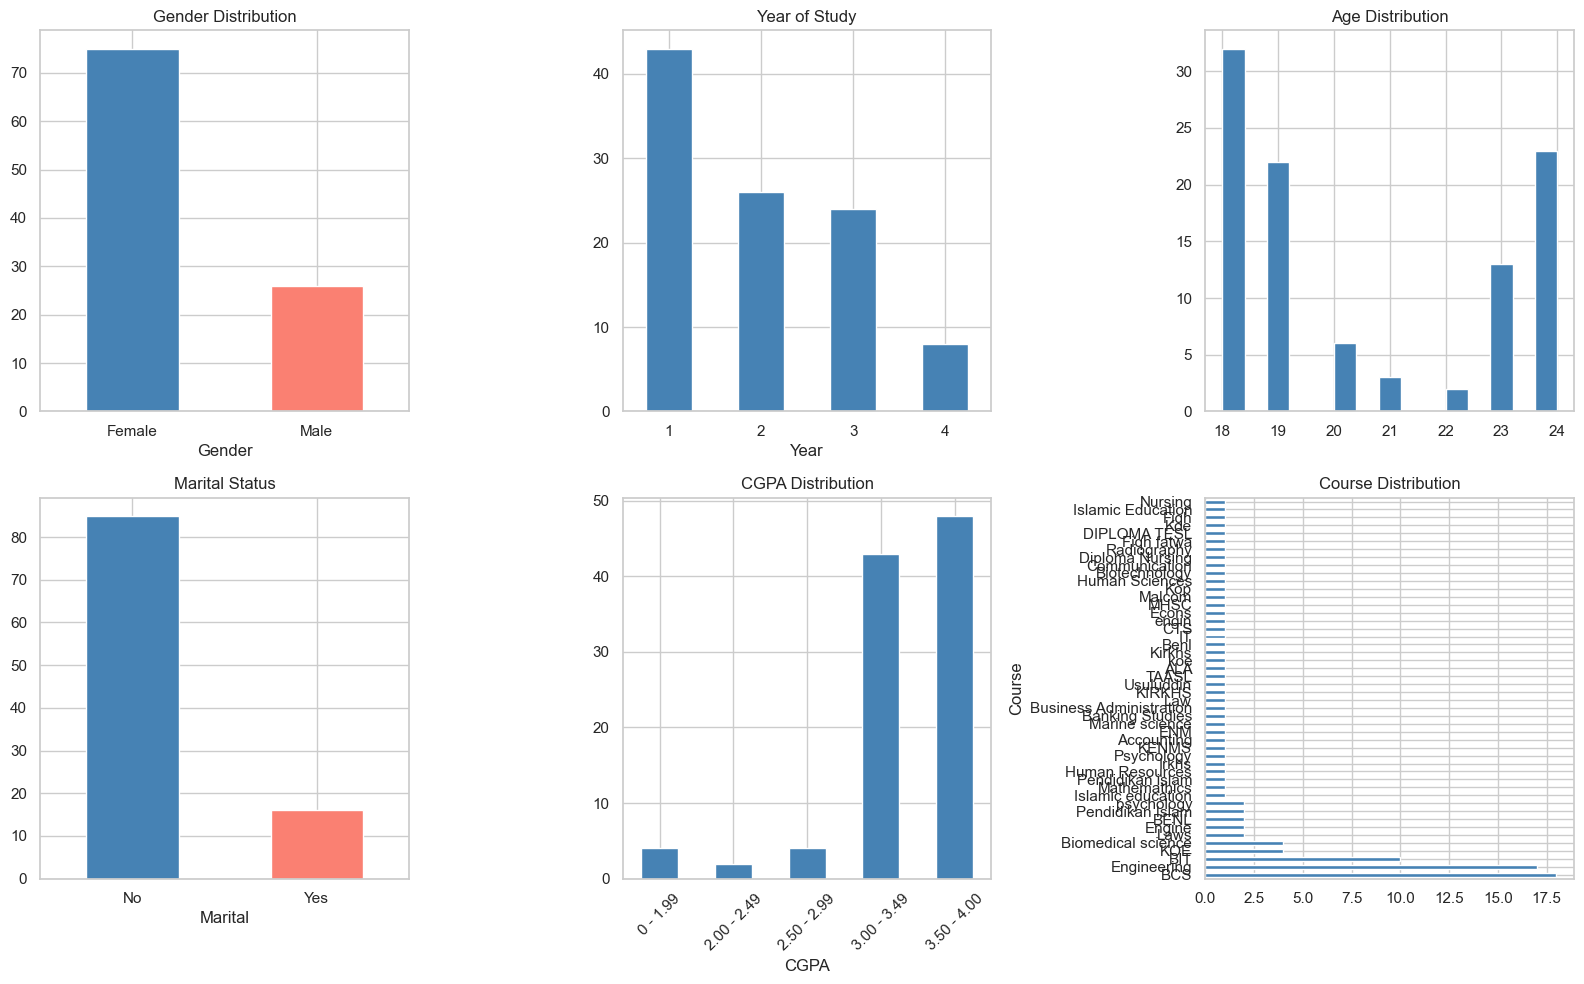

In [86]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Gender
df['Gender'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','salmon'])
axes[0,0].set_title('Gender Distribution')
axes[0,0].tick_params(axis='x', rotation=0)

# Year
df['Year'].value_counts().sort_index().plot(kind='bar', ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Year of Study')
axes[0,1].tick_params(axis='x', rotation=0)

# Age
axes[0,2].hist(df['Age'], bins=15, color='steelblue', edgecolor='white')
axes[0,2].set_title('Age Distribution')

# Marital Status
df['Marital'].value_counts().plot(kind='bar', ax=axes[1,0], color=['steelblue','salmon'])
axes[1,0].set_title('Marital Status')
axes[1,0].tick_params(axis='x', rotation=0)

# CGPA
df['CGPA'].value_counts().sort_index().plot(kind='bar', ax=axes[1,1], color='steelblue')
axes[1,1].set_title('CGPA Distribution')
axes[1,1].tick_params(axis='x', rotation=45)

# Course
df['Course'].value_counts().plot(kind='barh', ax=axes[1,2], color='steelblue')
axes[1,2].set_title('Course Distribution')

plt.tight_layout()
plt.show()

Insights:
- Female jauh lebih banyak yang ngisi. Ada kemungkinan modelnya bias dan lebih apal pola female.
- Mahasiswa tahun awal lebih sering ngisi.
- Pola age bentuknya kaya parabola, gede di awal dan akhir, di tengah dikit.
- Dikit banget yang nikah. Bisa dilihat nanti apakah yang nikah memiliki relation yang kuat ke kondisi tertentu.
- CGPA banyak yang di atas 3.00.
- Course terlalu sparse, cluttered banget, asli. Nanti di grouping dah mending.


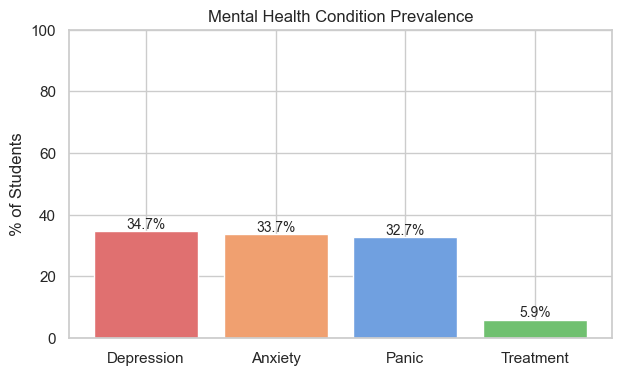

In [87]:
prevalence = df[MENTAL_COLS + ['Treatment']].apply(lambda col: (col == 'Yes').mean() * 100)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(prevalence.index, prevalence.values, color=['#e07070','#f0a070','#70a0e0','#70c070'])
ax.set_ylabel('% of Students')
ax.set_title('Mental Health Condition Prevalence')
ax.set_ylim(0, 100)

for bar, val in zip(bars, prevalence.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=10)

plt.show()

Lumayan rata, dan yang treatment dikit, menarik. Bisa diolah nanti

In [88]:
mental_binary = df[MENTAL_COLS].apply(lambda col: (col == 'Yes').astype(int))
combos = mental_binary.groupby(MENTAL_COLS).size().reset_index(name='Count').sort_values('Count', ascending=False)
print(combos.to_string(index=False))

 Depression  Anxiety  Panic  Count
          0        0      0     37
          0        0      1     13
          0        1      0     13
          1        0      0     10
          1        1      1     10
          1        1      0      8
          1        0      1      7
          0        1      1      3


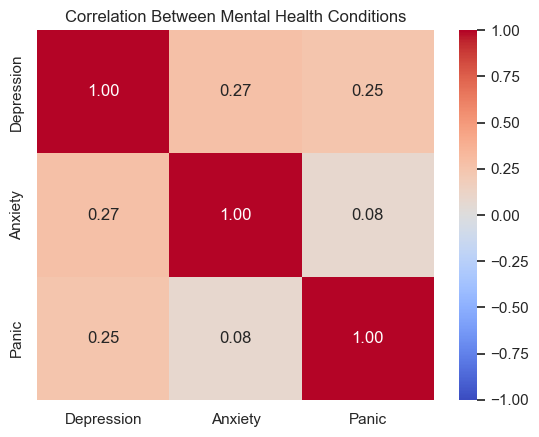

In [89]:
corr = mental_binary.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Between Mental Health Conditions')
plt.show()

Menarik, ga terlalu ada keterkaitan mutlak satu sama lain, mungkin nanti bisa diambil insightnya.

C:\Users\Inaka\AppData\Local\Temp\ipykernel_8156\2977316196.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ct, x='Gender', y='Pct', ax=ax, palette='Set2')
C:\Users\Inaka\AppData\Local\Temp\ipykernel_8156\2977316196.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ct, x='Gender', y='Pct', ax=ax, palette='Set2')
C:\Users\Inaka\AppData\Local\Temp\ipykernel_8156\2977316196.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ct, x='Gender', y='Pct', ax=ax, palette='Set2')


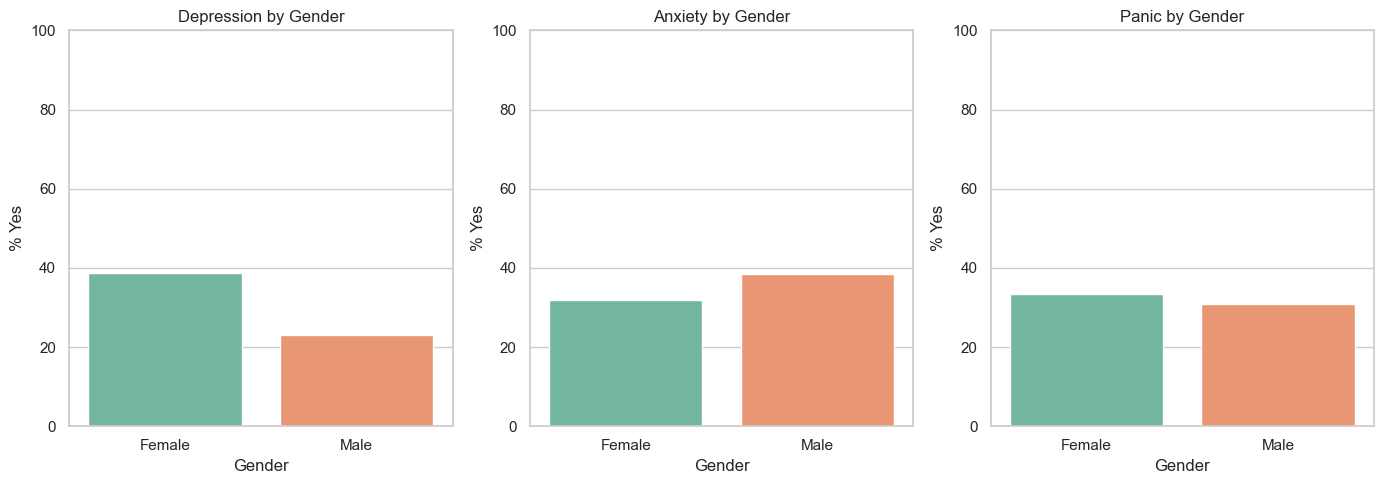

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('Gender')[col].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    ct.columns = ['Gender', 'Pct']
    sns.barplot(data=ct, x='Gender', y='Pct', ax=ax, palette='Set2')
    ax.set_title(f'{col} by Gender')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Tidak ada dominasi atau kecenderungan mutlak dari gender terhadap keadaan mental.

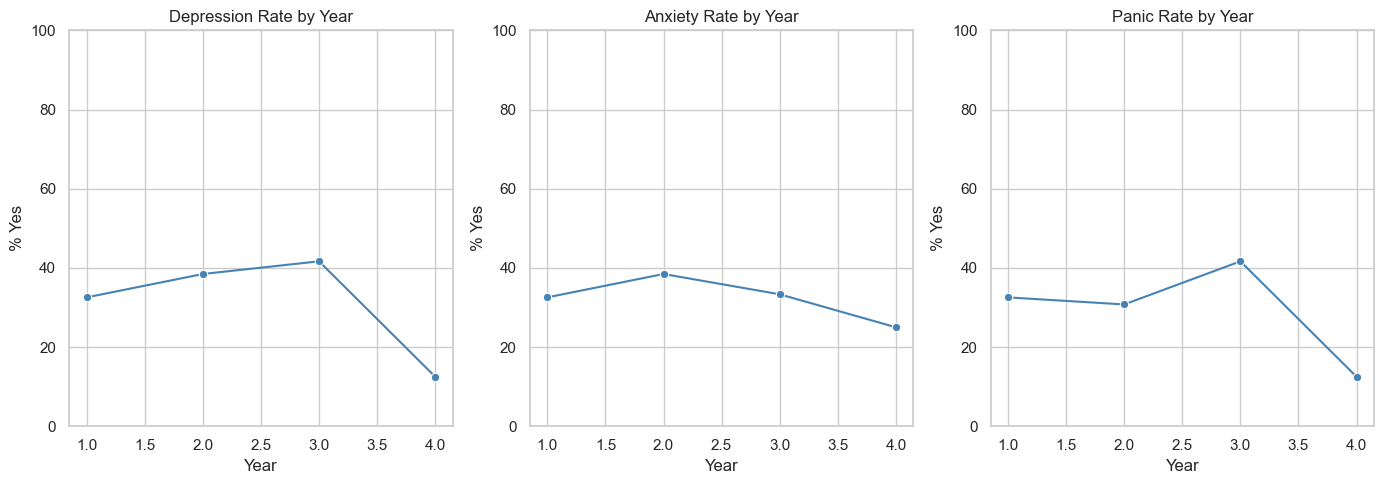

In [91]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('Year')[col].apply(lambda x: (x == 'Yes').mean() * 100).reset_index()
    ct.columns = ['Year', 'Pct']
    sns.lineplot(data=ct, x='Year', y='Pct', ax=ax, marker='o', color='steelblue')
    ax.set_title(f'{col} Rate by Year')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

Terlihat depresi dan panic rate paling tinggi ada di tahun ke 3, dan anxiety di tahun ke 2.

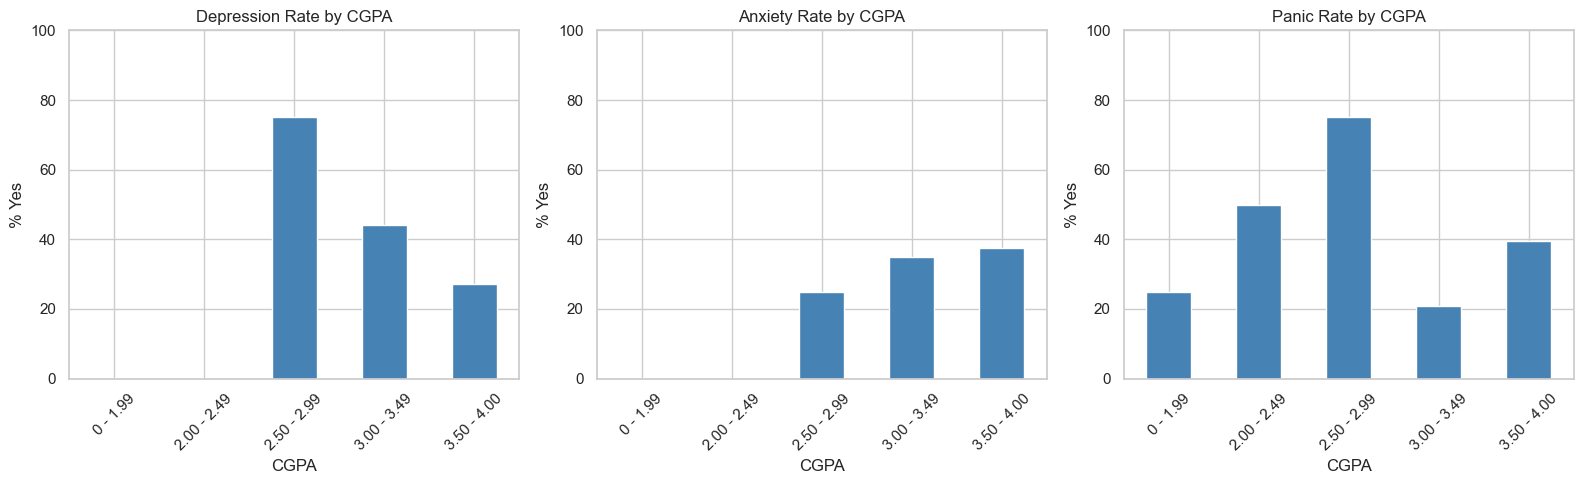

In [92]:
cgpa_order = sorted(df['CGPA'].unique())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col in zip(axes, MENTAL_COLS):
    ct = df.groupby('CGPA')[col].apply(lambda x: (x == 'Yes').mean() * 100).reindex(cgpa_order)
    ct.plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(f'{col} Rate by CGPA')
    ax.set_ylabel('% Yes')
    ax.set_ylim(0, 100)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Trennya unik? Depression rate tertinggi ada di mahasiswa dengan CGPA tinggi.

In [93]:
df['Any_condition'] = df[MENTAL_COLS].apply(lambda row: 'Yes' in row.values, axis=1)

ct = pd.crosstab(df['Any_condition'], df['Treatment'])
ct.index = ['No Condition', 'Has Condition']
ct.columns = ['No Treatment', 'Seeking Treatment']
print(ct)
print()
print("Of students WITH a condition, % seeking treatment:",
      round(ct.loc['Has Condition', 'Seeking Treatment'] / ct.loc['Has Condition'].sum() * 100, 1), "%")

               No Treatment  Seeking Treatment
No Condition             37                  0
Has Condition            58                  6

Of students WITH a condition, % seeking treatment: 9.4 %


Uih, SANGAT sedikit mahasiswa dengan setidaknya satu kondisi mental yang mencari pertolongan profesional

## d. Feature Engineering
Mulai otak-atik fitur, misal grouping, dll.

In [95]:
df['Course'].unique()

<StringArray>
[            'Engineering',       'Islamic education',
                     'BIT',                    'Laws',
            'Mathemathics',        'Pendidikan islam',
                     'BCS',         'Human Resources',
                   'Irkhs',              'Psychology',
                   'KENMS',              'Accounting',
                     'ENM',          'Marine science',
                     'KOE',         'Banking Studies',
 'Business Administration',                     'Law',
                  'KIRKHS',               'Usuluddin',
                   'TAASL',                  'Engine',
                     'ALA',      'Biomedical science',
                     'koe',                  'Kirkhs',
                    'BENL',                    'Benl',
                      'IT',                     'CTS',
                   'engin',                   'Econs',
                    'MHSC',                  'Malcom',
                     'Kop',          'Human Science

In [96]:
course_clean_mapping = {
    'Engineering'           : 'Engineering',
    'Engine'                : 'Engineering',
    'engin'                 : 'Engineering',
    'KOE'                   : 'Engineering',
    'koe'                   : 'Engineering',
    'Koe'                   : 'Engineering',
    'BCS'                   : 'BCS',
    'BIT'                   : 'BIT',
    'IT'                    : 'BIT',
    'CTS'                   : 'BIT',
    'Biomedical science'    : 'Biomedical Science',
    'Biotechnology'         : 'Biotechnology',
    'Mathemathics'          : 'Mathematics',
    'Marine science'        : 'Marine Science',
    'Islamic education'     : 'Islamic Education',
    'Islamic Education'     : 'Islamic Education',
    'Pendidikan islam'      : 'Islamic Education',
    'Pendidikan Islam'      : 'Islamic Education',
    'Irkhs'                 : 'Islamic Education',
    'KIRKHS'                : 'Islamic Education',
    'Kirkhs'                : 'Islamic Education',
    'Fiqh fatwa'            : 'Islamic Education',
    'Fiqh'                  : 'Islamic Education',
    'Usuluddin'             : 'Islamic Education',
    'MHSC'                  : 'Islamic Education',
    'Malcom'                : 'Islamic Education',
    'BENL'                  : 'English Language',
    'Benl'                  : 'English Language',
    'TAASL'                 : 'English Language',
    'ALA'                   : 'English Language',
    'DIPLOMA TESL'          : 'English Language',
    'Human Resources'       : 'Human Sciences',
    'Human Sciences'        : 'Human Sciences',
    'Psychology'            : 'Psychology',
    'psychology'            : 'Psychology',
    'Laws'                  : 'Law',
    'Law'                   : 'Law',
    'Nursing'               : 'Nursing',
    'Diploma Nursing'       : 'Nursing',
    'Radiography'           : 'Radiography',
    'Communication'         : 'Communication',
    'Econs'                 : 'Economics',
    'ENM'                   : 'Economics',
    'KENMS'                 : 'Economics',
    'Business Administration': 'Business Administration',
    'Banking Studies'       : 'Banking Studies',
    'Accounting'            : 'Accounting',
    'Kop'                   : 'Pharmacy',
}

In [97]:
rumpun_mapping = {
    # STEM
    'Engineering'           : 'STEM',
    'BCS'                   : 'STEM',
    'BIT'                   : 'STEM',
    'Biomedical Science'    : 'STEM',
    'Biotechnology'         : 'STEM',
    'Mathematics'           : 'STEM',
    'Marine Science'        : 'STEM',
    'Pharmacy'              : 'STEM',

 
    # Social & Humanities (termasuk Islamic Education, Health, Language)
    'Islamic Education'     : 'Social & Humanities',
    'English Language'      : 'Social & Humanities',
    'Human Sciences'        : 'Social & Humanities',
    'Psychology'            : 'Social & Humanities',
    'Law'                   : 'Social & Humanities',
    'Nursing'               : 'Social & Humanities',
    'Radiography'           : 'Social & Humanities',
    'Communication'         : 'Social & Humanities',
 
    # Business & Economics
    'Economics'             : 'Business & Economics',
    'Business Administration': 'Business & Economics',
    'Banking Studies'       : 'Business & Economics',
    'Accounting'            : 'Business & Economics',
 }

In [98]:
df['Course_clean'] = df['Course'].map(course_clean_mapping)
df['Course_group'] = df['Course_clean'].map(rumpun_mapping)

In [99]:
unmapped = df[df['Course_group'].isna()]['Course'].unique()
if len(unmapped) > 0:
    print("Unmapped:", unmapped)
else:
    print("Mapping ok")

Mapping ok


In [100]:
print("Detail Mapping")
detail = df.groupby('Course_group')['Course_clean'].apply(lambda x: sorted(x.unique())).reset_index()
for _, row in detail.iterrows():
    print(f"\n  [{row['Course_group']}]")
    for c in row['Course_clean']:
        print(f"    - {c}")
 
print("\n=== DISTRIBUSI FINAL ===")
dist = df['Course_group'].value_counts()
for group, count in dist.items():
    bar = '█' * count
    pct = count / len(df) * 100
    print(f"  {group:<25} {count:>3} ({pct:4.1f}%)  {bar}")

Detail Mapping

  [Business & Economics]
    - Accounting
    - Banking Studies
    - Business Administration
    - Economics

  [STEM]
    - BCS
    - BIT
    - Biomedical Science
    - Biotechnology
    - Engineering
    - Marine Science
    - Mathematics
    - Pharmacy

  [Social & Humanities]
    - Communication
    - English Language
    - Human Sciences
    - Islamic Education
    - Law
    - Nursing
    - Psychology
    - Radiography

=== DISTRIBUSI FINAL ===
  STEM                       64 (63.4%)  ████████████████████████████████████████████████████████████████
  Social & Humanities        31 (30.7%)  ███████████████████████████████
  Business & Economics        6 ( 5.9%)  ██████


In [101]:
def risk_level(row):
    score = (row['Depression']=='Yes') + (row['Anxiety']=='Yes') + (row['Panic']=='Yes')
    if score == 0: return 'Low'
    elif score == 1: return 'Medium'
    else: return 'High'
    
df['Risk_Level'] = df.apply(risk_level, axis=1)
 
print("\nRisk Level Per Rumpun")
ct = pd.crosstab(df['Course_group'], df['Risk_Level'])
ct['Total'] = ct.sum(axis=1)
ct['High%'] = (ct.get('High', 0) / ct['Total'] * 100).round(1)
print(ct.to_string())


Risk Level Per Rumpun
Risk_Level            High  Low  Medium  Total  High%
Course_group                                         
Business & Economics     2    3       1      6   33.3
STEM                    16   23      25     64   25.0
Social & Humanities     10   11      10     31   32.3


In [102]:
df

,Gender,Age,Course,Year,CGPA,Marital,Depression,Anxiety,Panic,Treatment,Any_condition,Course_clean,Course_group,Risk_Level
0,Female,18.0,Engineering,1,3.00 - 3.49,No,Yes,No,Yes,No,True,Engineering,STEM,High
1,Male,21.0,Islamic education,2,3.00 - 3.49,No,No,Yes,No,No,True,Islamic Education,Social & Humanities,Medium
2,Male,19.0,BIT,1,3.00 - 3.49,No,Yes,Yes,Yes,No,True,BIT,STEM,High
3,Female,22.0,Laws,3,3.00 - 3.49,Yes,Yes,No,No,No,True,Law,Social & Humanities,Medium
4,Male,23.0,Mathemathics,4,3.00 - 3.49,No,No,No,No,No,False,Mathematics,STEM,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,BCS,1,3.50 - 4.00,No,No,Yes,No,No,True,BCS,STEM,Medium
97,Male,18.0,Engineering,2,3.00 - 3.49,No,Yes,Yes,No,No,True,Engineering,STEM,High
98,Female,19.0,Nursing,3,3.50 - 4.00,Yes,Yes,No,Yes,No,True,Nursing,Social & Humanities,High
99,Female,23.0,Pendidikan Islam,4,3.50 - 4.00,No,No,No,No,No,False,Islamic Education,Social & Humanities,Low


In [103]:
df.drop(['Course', 'Depression', 'Anxiety', 'Panic'], axis=1, inplace=True)
df.rename(columns={'Course_clean': 'Course'}, inplace=True)

In [104]:
df

,Gender,Age,Year,CGPA,Marital,Treatment,Any_condition,Course,Course_group,Risk_Level
0,Female,18.0,1,3.00 - 3.49,No,No,True,Engineering,STEM,High
1,Male,21.0,2,3.00 - 3.49,No,No,True,Islamic Education,Social & Humanities,Medium
2,Male,19.0,1,3.00 - 3.49,No,No,True,BIT,STEM,High
3,Female,22.0,3,3.00 - 3.49,Yes,No,True,Law,Social & Humanities,Medium
4,Male,23.0,4,3.00 - 3.49,No,No,False,Mathematics,STEM,Low
...,...,...,...,...,...,...,...,...,...,...
96,Female,21.0,1,3.50 - 4.00,No,No,True,BCS,STEM,Medium
97,Male,18.0,2,3.00 - 3.49,No,No,True,Engineering,STEM,High
98,Female,19.0,3,3.50 - 4.00,Yes,No,True,Nursing,Social & Humanities,High
99,Female,23.0,4,3.50 - 4.00,No,No,False,Islamic Education,Social & Humanities,Low


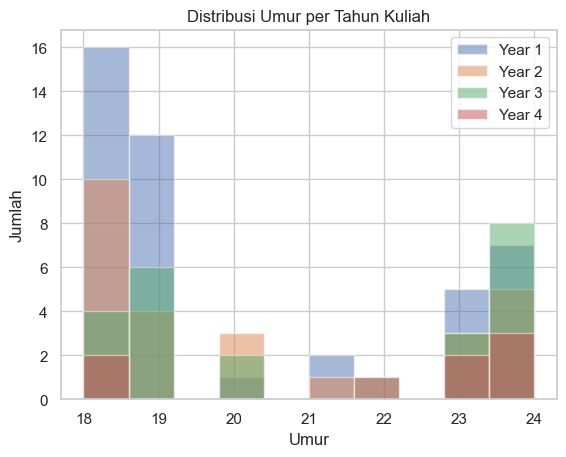

In [105]:
import matplotlib.pyplot as plt

for year in sorted(df['Year'].unique()):
    plt.hist(df[df['Year'] == year]['Age'], alpha=0.5, label=f'Year {year}')

plt.xlabel('Umur')
plt.ylabel('Jumlah')
plt.title('Distribusi Umur per Tahun Kuliah')
plt.legend()

plt.show()

In [106]:
distribusi_umur = pd.crosstab(df['Year'], df['Age'])
print(distribusi_umur)

Age   18.0  19.0  20.0  21.0  22.0  23.0  24.0
Year                                          
1       16    12     1     2     0     5     7
2       10     4     3     1     0     3     5
3        4     6     2     0     1     3     8
4        2     0     0     0     1     2     3
